## BME 230 - Modeling counts

**The dataset**

Following an analysis perfomed in [Svensson et al. 2020](https://www.nature.com/articles/s41587-019-0379-5)  we will be analyzing negative control data made by the indrops platform. This negative control was made by adding RNA directly to fluid of microfluidic devices, so that each droplet generated has identical RNA content. Thus we can get a more rigorous sense of the zero counts of genes per droplet (and by proxy per cell) by this single-cell technology. This also allows for analysis of whether zero counts of genes are due to technical limitations or biological variation in cells.

**The Count matrix**

This matrix is 953 droplets by 25,435 genes, from [Klein et al. 2015](https://www.sciencedirect.com/science/article/pii/S0092867415005000?via%3Dihub). Total RNA (to mimic the amount of RNA in a cell, per droplet) and RNA samples at known concentrations are spiked-in to the microfluidic fluid, encapsulated by each droplet.





 

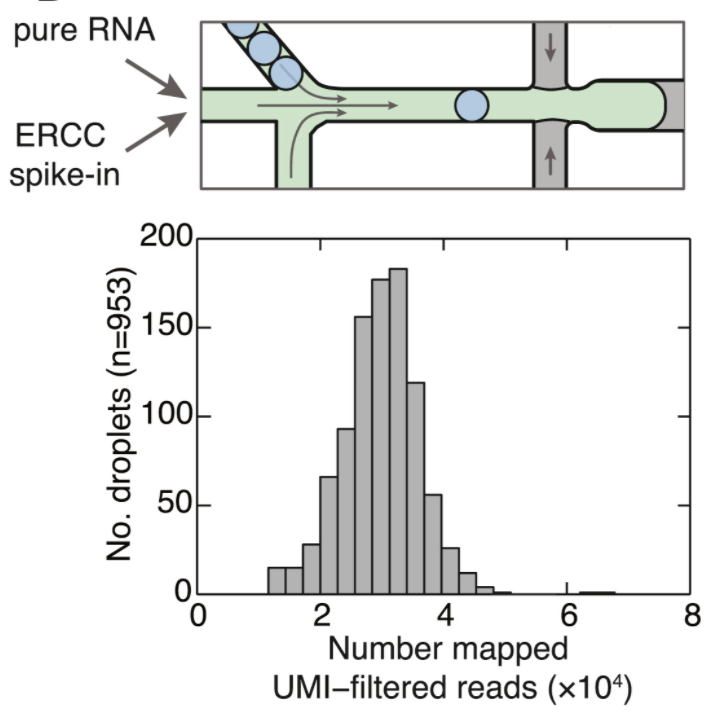

In [6]:
img_path = "/cnt_distn.png"
display(Image.open(img_path))


For this problem you will be exploring models which can be used to describe count data i.e. the gene-count matrices we use in single-cell. Single-cell gene counts, which describe stochastically sampled, discrete measurements of UMI counts, are often modeled as being generated from a negative binomial (or Gamma-Poisson) distribution.

#### Import data and install packages.

In [5]:
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt #Can use other plotting packages like seaborn

import anndata

from scipy import optimize
from scipy.special import gammaln
from scipy.special import psi
from scipy.special import factorial
from scipy.optimize import fmin_l_bfgs_b as optim
import requests
from tqdm import tnrange, tqdm_notebook

In [2]:
def download_file(doi,ext):
    url = 'https://api.datacite.org/dois/'+doi+'/media'
    r = requests.get(url).json()
    netcdf_url = r['data'][0]['attributes']['url']
    r = requests.get(netcdf_url,stream=True)
    #Set file name
    fname = doi.split('/')[-1]+ext
    #Download file with progress bar
    if r.status_code == 403:
        print("File Unavailable")
    if 'content-length' not in r.headers:
        print("Did not get file")
    else:
        with open(fname, 'wb') as f:
            total_length = int(r.headers.get('content-length'))
            pbar = tnrange(int(total_length/1024), unit="B")
            for chunk in r.iter_content(chunk_size=1024):
                if chunk:
                    pbar.update()
                    f.write(chunk)
        return fname

download_file('10.22002/xsret-sb590','.gz')


/var/folders/36/f1rzmyv56yzgq_15q20yft_m0000gn/T/ipykernel_42525/4287163176.py:18: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`
  pbar = tnrange(int(total_length/1024), unit="B")


  0%|          | 0/19383 [00:00<?, ?B/s]

'xsret-sb590.gz'

!gunzip *.gz
!mv xsret-sb590 Klein.h5ad

In [4]:
indrops = anndata.read('Klein.h5ad')
indrops

/opt/anaconda3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 953 × 25435
    obs: 'total_counts'
    var: 'empirical_mean', 'empirical_variance', 'empirical_zero_fraction', 'ml_mean', 'genewise_dispersion', 'global_zero_fraction', 'genewise_zero_fraction', 'scaled_count_mean', 'poisson_zero_fraction'
    uns: 'global_dispersion', 'name'

## Problem 1 

The Poisson distribution expresses the probability of some $x$ number of events occurring in a fixed interval of time/space, with these events occuring at a known constant mean rate $\lambda$ (and independently of time since the last event).

The Poisson model is
\begin{align}
f(x; \lambda)= \Pr(X{=}x)= \frac{\lambda^x e^{-\lambda}}{x!}.
\end{align}

The negative binomial (NB) distribution describes the probability of seeing $x$ failures until some $r$ successes have occurred, with $p$ denoting the probability of success. 'Successes' can be thought of read counts here i.e the event that a read is a count for a given gene.

The NB model ($\text{NB}
(r,p)$) is
\begin{align}
f(x;r,p)\equiv \Pr(X=x)={\binom {x+r-1}{r-1}}(1-p)^{x}p^{r}
\end{align}

The Poisson distribution can be written as special case of the NB where $ \operatorname {Poisson} (\lambda )=\lim _{r\to \infty }\operatorname {NB} \left(r,{\frac {\lambda }{r+\lambda }}\right)$, with $p ={\frac {\lambda }{r+\lambda }}$.

Note: We can also denote $r,p$ as $\mu,\phi$ where $\mu$ represent the mean and $\phi$ represents the dispersion parameter. Here $p = \dfrac{r}{r + \mu}$ and $r = \dfrac{1}{\phi}$.

This convention is also common in the single-cell literature.


**(a) Plot mean versus variance of expression for all genes (across all cells) and comment on what trends you notice between the two (e.g. overdispersion etc).**

**(b)Fit Poisson and NB models for the first 100 genes.**

Fit and save the parameters for these two models for the first 100 genes $g$.

For the Poisson models we can use the MLE estimate for $\lambda$ which is $\dfrac{1}{n}\sum_{i=1}^n x_{i,g}$.

For the NB $r \text{ and } p$ cannot (concurrently) be derived analytically. You can use the **fit_nbinom(X)** function defined below to obtain $r \text{ and } p$ fits for each gene.

Report the parameter fits for the first 10 genes.


In [8]:
# X = numpy array of the data (e.g. 1D array with all the counts for one gene)
# initial params is a numpy array representing the initial values of
# size and prob parameters
# Returns: Dict with 'r' and 'p' fits
def fit_nbinom(X, initial_params=None):
    
    infinitesimal = np.finfo(np.float).eps

    def log_likelihood(params, *args):
        r, p = params
        X = args[0]
        N = X.size

        # MLE estimate based on the formula on Wikipedia:
        # http://en.wikipedia.org/wiki/Negative_binomial_distribution#Maximum_likelihood_estimation
        
        result = np.sum(gammaln(X + r)) \
            - np.sum(np.log(factorial(X))) \
            - N * (gammaln(r)) \
            + N * r * np.log(p) \
            + np.sum(X * np.log(1 - (p if p < 1 else 1 - infinitesimal)))

        return -result

    if initial_params is None:
        # reasonable initial values (from fitdistr function in R)
        m = np.mean(X)
        v = np.var(X)
        size = (m ** 2) / (v-m) if v > m else 10

        # convert mu/size parameterization to prob/size
        p0 = size / ((size + m) if size + m != 0 else 1)
        r0 = size
        initial_params = np.array([r0, p0])

    bounds = [(infinitesimal, None), (infinitesimal, 1)]
    optimres = optim(log_likelihood,
                     x0=initial_params,
                     args=(X,),
                     approx_grad=1,
                     bounds=bounds)

    params = optimres[0]
    return {'r': params[0], 'p': params[1]}

## Problem 2 
Suppose $x = (x_1, x_2, \dots, x_n)$ are i.i.d. observations from a Poisson random variable with unknown parameter $\lambda$.

Write down the log-likelihood function $L(\lambda \mid x)$ for this set of observations.



## Problem 3 
**If working by hand attach an image of your work, or directly type your answer into a text cell.**


Consider two independent geometric random variables, $X$ and $Y$, with identical probability mass function:

$$
P(X = k) = (1 - p)^{k-1} p, \quad \text{where } k = 1, 2, 3, \dots
$$

where $p$ is a parameter of the distribution.

(a) Show that: $$ P(X + Y = k) = (k - 1)(1 - p)^{k-2} p^2, \quad \text{for } k = 2, 3, \dots $$


(b) The sum of $n$ i.i.d. geometric random variables with parameter $p$ has a negative binomial distribution with parameters $r=n$ and $p$.

Draw 10,000 samples from a negative binomial distribution with $r=10$, $p=0.5$ and plot your sampled values in the form of a histogram. 

You may **not** use functions that directly generate samples from a negative binomial distribution such as `numpy.random.negative_binomial`.



In [23]:
# your code below for (b) : 
